In [9]:
import pandas as pd
import kagglehub
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Загрузка данных

In [6]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "shivam2503/diamonds"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/diamonds.csv")

print(df.head())
print(df.info())
print(df.describe())
duplicates_count = df.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates_count}")

Dataset path: data/kagglehub_cache\datasets\shivam2503\diamonds\versions\1
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    

# Визуализация данных

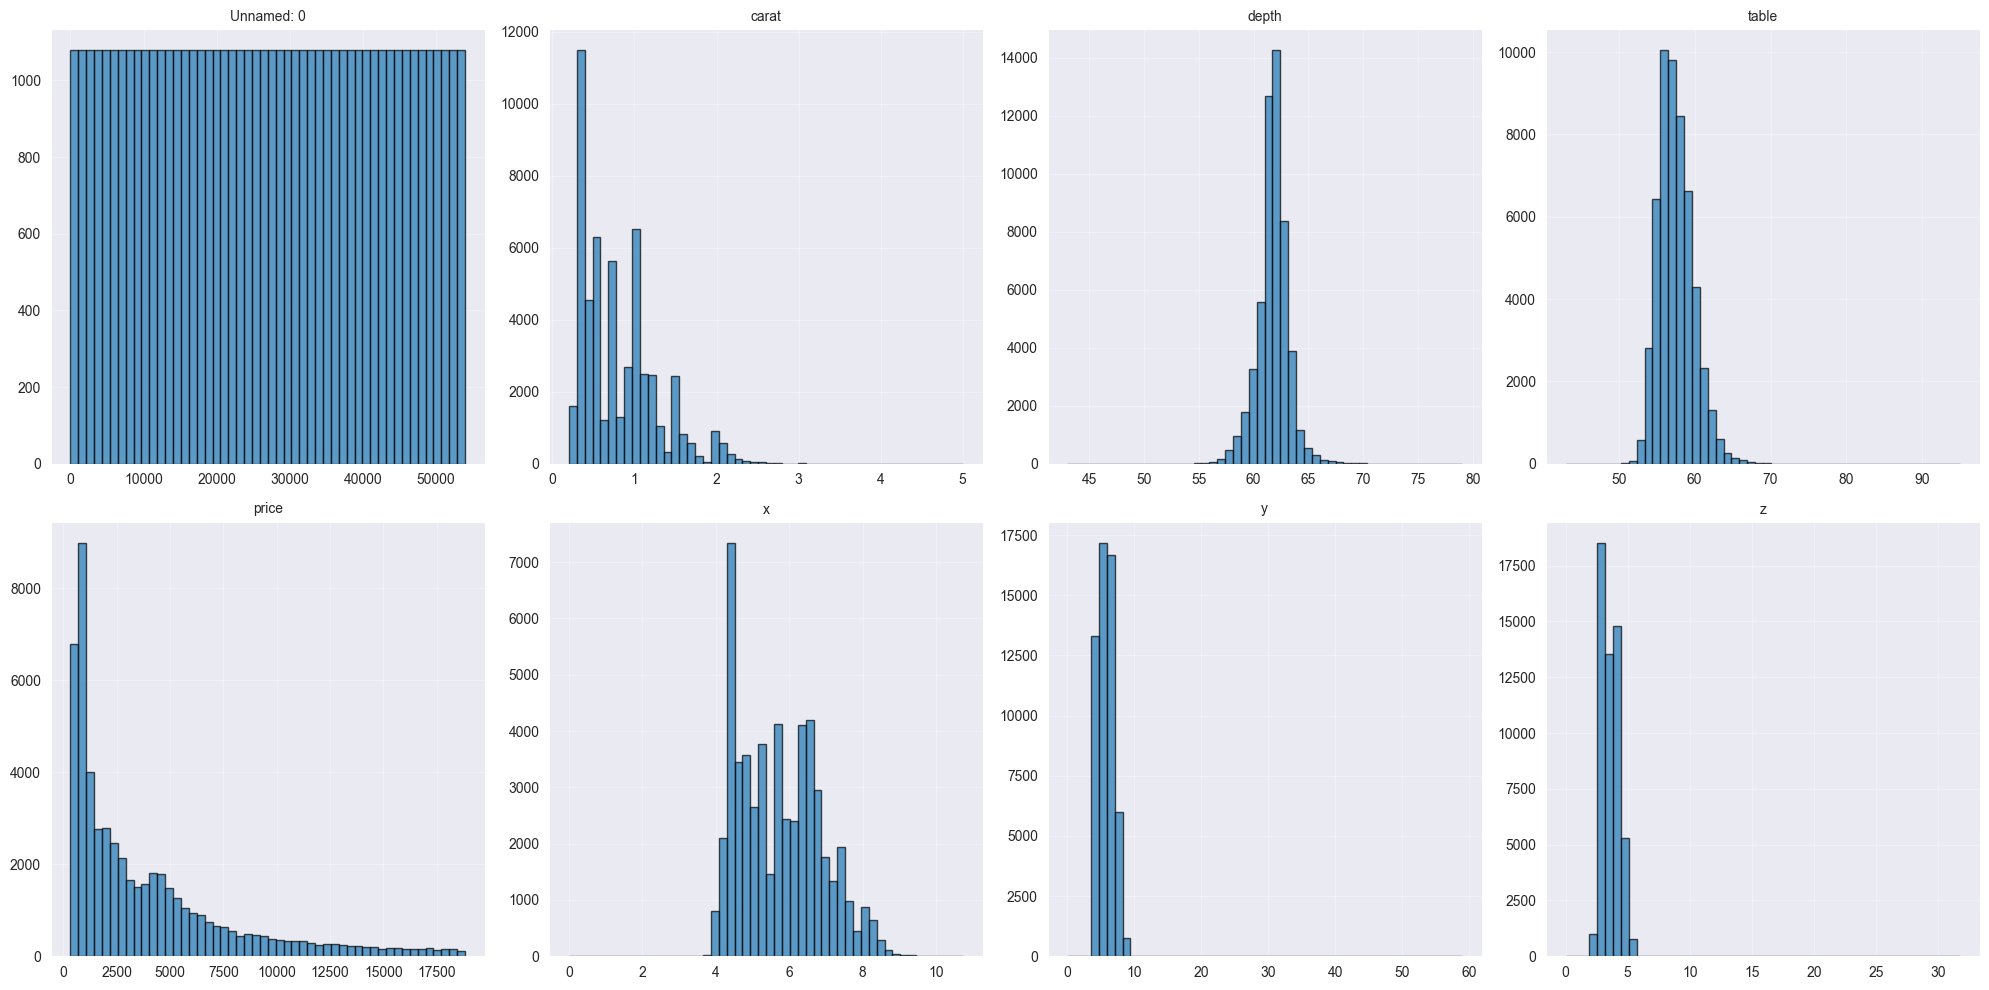

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Анализ корреляции признаков
Коррелияции с целевой колонкой

ТОП-10 корреляций с Price:
price         1.000000
carat         0.921591
x             0.884435
y             0.865421
z             0.861249
Unnamed: 0    0.306873
table         0.127134
depth         0.010647
Name: price, dtype: float64




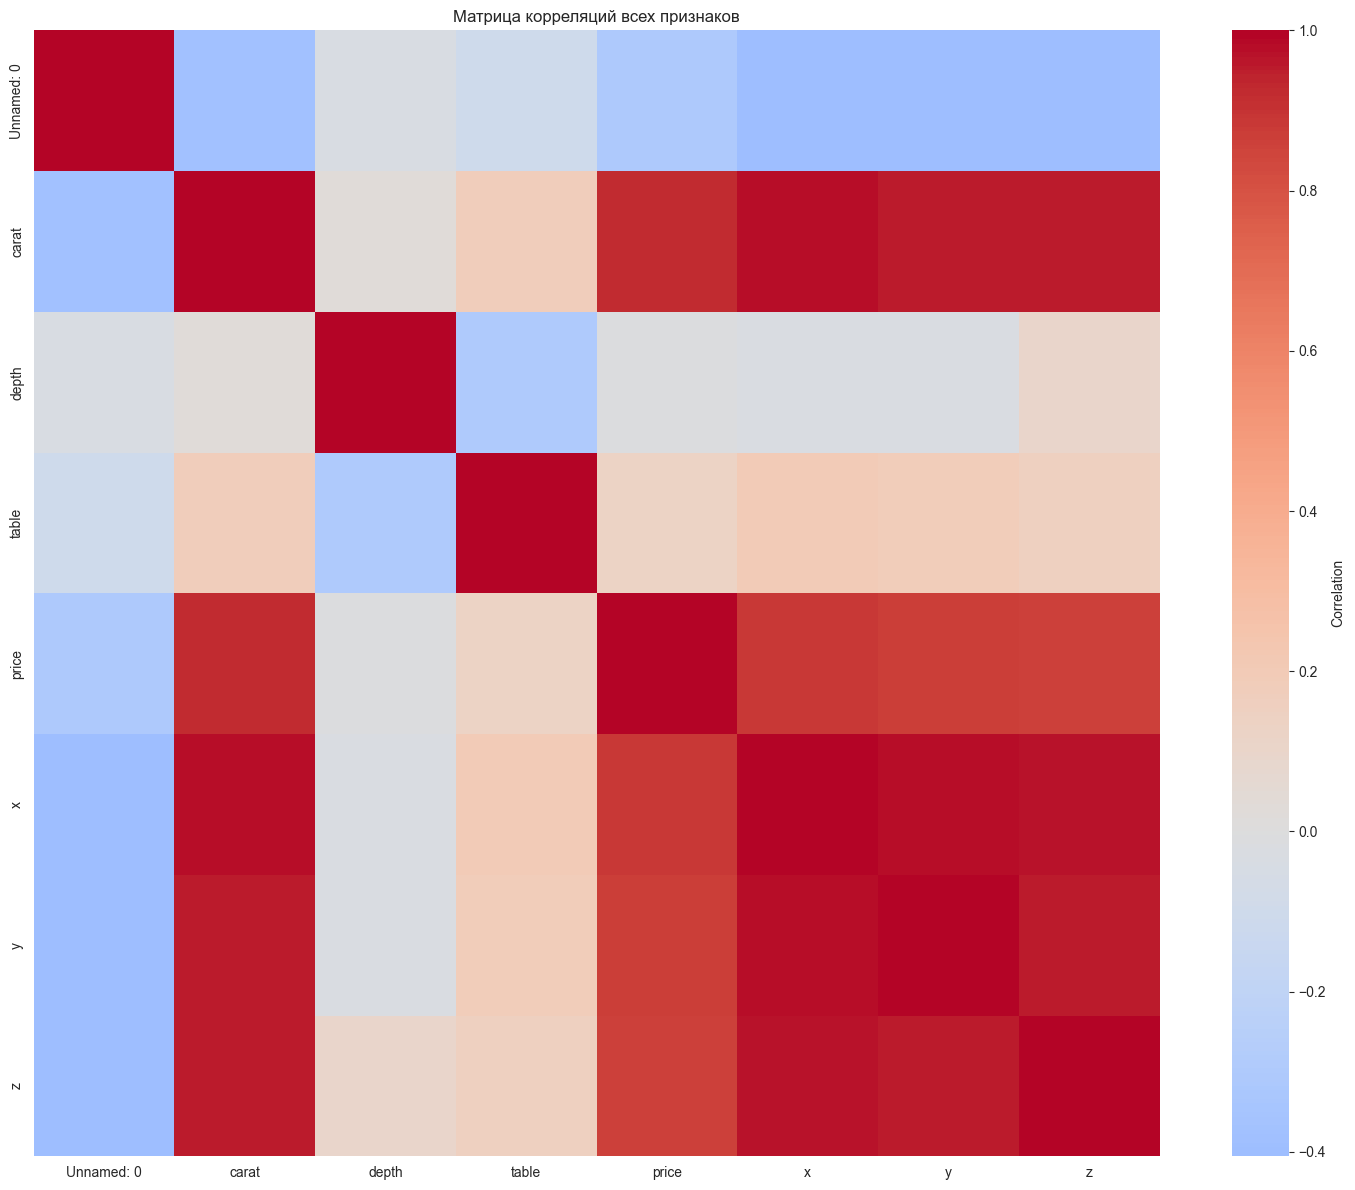

In [10]:
target = 'price'
numeric_df = df.select_dtypes(include=[np.number])  # Только числовые колонки


target_corr = numeric_df.corr()[target].abs().sort_values(ascending=False)
print("ТОП-10 корреляций с Price:")
print(target_corr.head(10))
print("\n" + "="*60 + "\n")

corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Матрица корреляций всех признаков')
plt.tight_layout()
plt.show()

Взаимные корреляции признаков

In [11]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

print("Пары с высокой корреляцией:")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1:15} - {feat2:15} = {corr:.4f}")

Пары с высокой корреляцией:
x               - carat           = 0.9751
y               - x               = 0.9747
z               - x               = 0.9708
z               - carat           = 0.9534
z               - y               = 0.9520
y               - carat           = 0.9517
price           - carat           = 0.9216


# Подготовка выборок

In [14]:
target_col = 'price'
exclude_cols = ['price', 'Unnamed: 0', 'carat']

feature_cols = df.columns

print("Все признаки до очистки:", feature_cols)
print(f"Количество признаков до очистки: {len(feature_cols)}")

feature_cols = [col for col in df.columns if col not in exclude_cols]

print("\nИспользуемые признаки:", feature_cols)

numeric_features = ['depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категорий категориальных: {len(categorical_features)}")

Все признаки до очистки: Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')
Количество признаков до очистки: 11

Используемые признаки: ['cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
Числовых признаков: 5
Категорий категориальных: 3


# Предобработка данных

In [15]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# Random Forest
Модель

In [16]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=25,
        random_state=42
    ))
])

Обучение

In [17]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

RMSE: 855.24
R²: 0.9540
